# Sales Analysis — Olist E-Commerce

Analyzing sales trends, revenue, and order patterns using the cleaned `analysis_df` 
built in `01_data_cleaning.ipynb`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

analysis_df = pd.read_csv('../data/analysis_df.csv')

# Re-convert date columns — CSV doesn't preserve datetime dtype
date_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date', 
             'order_estimated_delivery_date', 'shipping_limit_date']
for col in date_cols:
    analysis_df[col] = pd.to_datetime(analysis_df[col])

print(analysis_df.shape)
analysis_df.dtypes

(112650, 34)


order_id                                 object
order_item_id                             int64
product_id                               object
seller_id                                object
shipping_limit_date              datetime64[ns]
price                                   float64
freight_value                           float64
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            object
customer_state                           object
product_category_name                    object
product_name_lenght                     float64
product_description_lenght              

## 2. Monthly Revenue & Order Volume Trend

**Question:** How have revenue and order volume changed over time?

In [2]:
analysis_df['order_month'] = analysis_df['order_purchase_timestamp'].dt.to_period('M')

monthly = analysis_df.groupby('order_month').agg(
    total_revenue=('price', 'sum'),
    order_count=('order_id', 'nunique')
).reset_index()

monthly['order_month'] = monthly['order_month'].astype(str)
monthly

,order_month,total_revenue,order_count
0,2016-09,267.36,3
1,2016-10,49507.66,308
2,2016-12,10.90,1
3,2017-01,120312.87,789
4,2017-02,247303.02,1733
5,2017-03,374344.30,2641
6,2017-04,359927.23,2391
7,2017-05,506071.14,3660
8,2017-06,433038.60,3217
9,2017-07,498031.48,3969


**Note:** Sep 2016, Dec 2016, and Sep 2018 have only 1–3 orders — these represent the platform's 
early pilot period and the dataset's cutoff mid-month, not real business volume. They're excluded 
from the trend visualization below to avoid a misleading drop at the edges, but remain in the 
underlying `monthly` table.

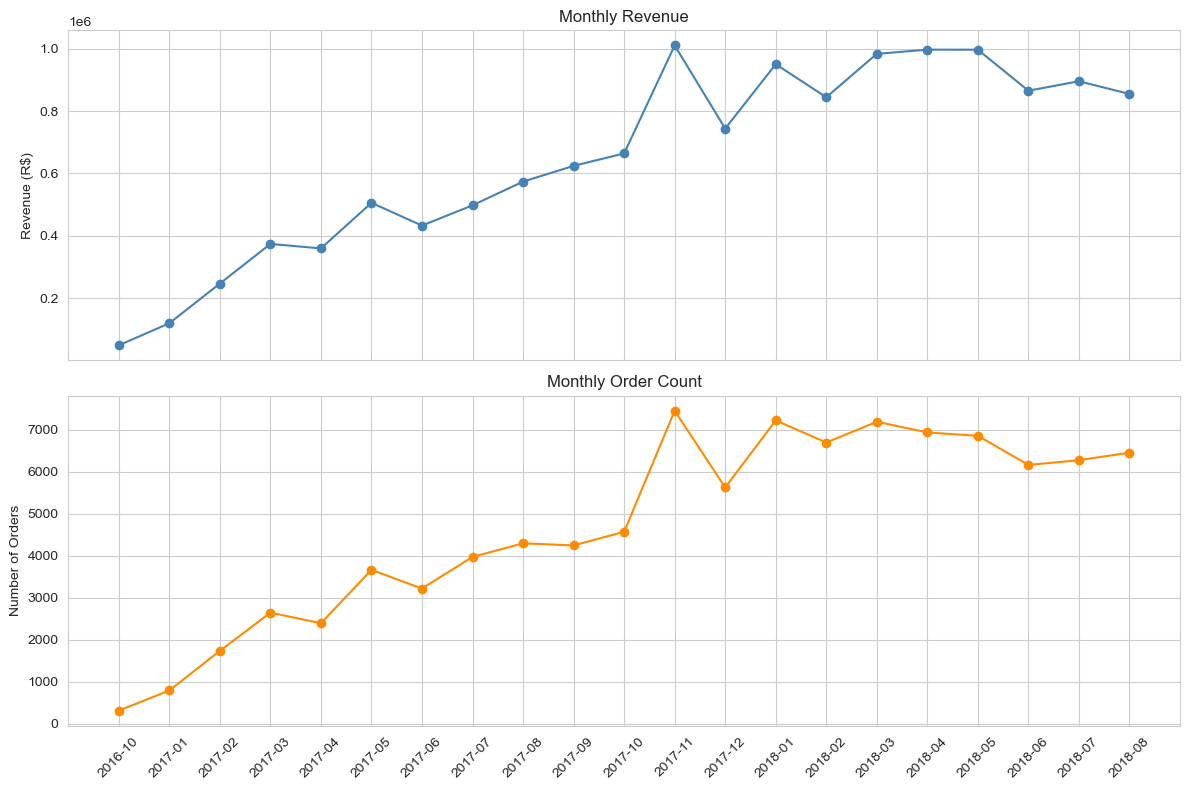

In [4]:
# Exclude near-empty edge months for the trend chart only
monthly_trend = monthly[~monthly['order_month'].isin(['2016-09', '2016-12', '2018-09'])]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(monthly_trend['order_month'], monthly_trend['total_revenue'], marker='o', color='steelblue')
axes[0].set_title('Monthly Revenue')
axes[0].set_ylabel('Revenue (R$)')

axes[1].plot(monthly_trend['order_month'], monthly_trend['order_count'], marker='o', color='darkorange')
axes[1].set_title('Monthly Order Count')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../images/monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight** Monthly revenue grew consistently through 2017, peaking sharply in November 2017 (R 1.01M, likely driven by Black Friday) before plateauing at R$ 850K–1M/month through mid-2018 — suggesting the business matured from a growth phase into a stable-volume phase within about 18 months.

## 3. Seasonality — Which Months Sell Best

**Question:** Independent of overall business growth, which calendar months see the strongest sales?

**Note:** The dataset spans Sep 2016 – Sep 2018. Months Jan–Aug have 2 years of data (2017 & 2018), 
while Sep, Oct, Nov, Dec only have 1 full year (2017). Raw totals would unfairly make the 
1-year months look weaker, so revenue is normalized to an average-per-year basis for fair comparison.

In [5]:
analysis_df['month_name'] = analysis_df['order_purchase_timestamp'].dt.month_name()
analysis_df['month_num'] = analysis_df['order_purchase_timestamp'].dt.month

# Exclude the near-empty pilot/cutoff months identified in Q1
clean_orders = analysis_df[~analysis_df['order_month'].astype(str).isin(['2016-09', '2016-12', '2018-09'])]

seasonal = clean_orders.groupby(['month_num', 'month_name']).agg(
    total_revenue=('price', 'sum'),
    order_count=('order_id', 'nunique')
).reset_index().sort_values('month_num')

# Normalize: months 1-8 have 2 years of coverage, months 9-12 have 1 year
seasonal['years_covered'] = seasonal['month_num'].apply(lambda m: 2 if m <= 8 else 1)
seasonal['avg_revenue_per_year'] = seasonal['total_revenue'] / seasonal['years_covered']
seasonal['avg_orders_per_year'] = seasonal['order_count'] / seasonal['years_covered']

seasonal[['month_name', 'avg_revenue_per_year', 'avg_orders_per_year']]

,month_name,avg_revenue_per_year,avg_orders_per_year
0,January,535171.615,4004.5
1,February,545740.865,4213.5
2,March,678778.870,4914.5
3,April,678287.490,4662.5
4,May,751294.410,5256.5
5,June,649081.455,4688.5
6,July,696769.350,5121.0
7,August,714329.005,5372.5
8,September,624401.690,4243.0
9,October,713727.090,4876.0


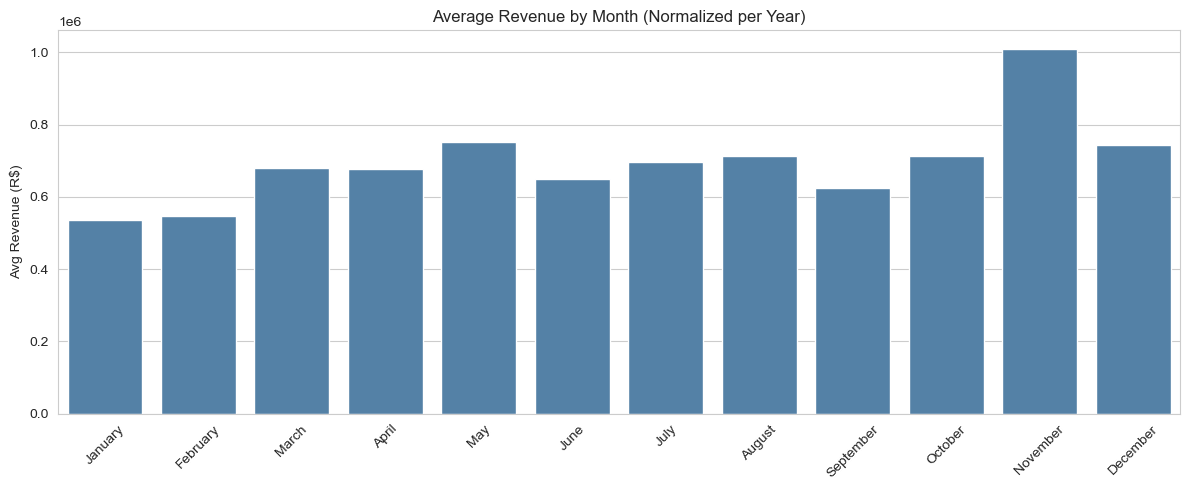

In [6]:
plt.figure(figsize=(12, 5))
sns.barplot(data=seasonal, x='month_name', y='avg_revenue_per_year', color='steelblue')
plt.title('Average Revenue by Month (Normalized per Year)')
plt.ylabel('Avg Revenue (R$)')
plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/seasonal_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight** November is the clear seasonal peak, generating ~40% more revenue than the average month — driven by Black Friday. Outside November, demand is relatively stable year-round, with a modest dip in January-February (post-holiday slowdown) and a secondary peak in December.

## 4. Average Order Value (AOV) & Distribution

**Question:** What does a typical order look like, in terms of value?

In [7]:
order_value = analysis_df.groupby('order_id').agg(
    order_value=('price', 'sum'),
    order_freight=('freight_value', 'sum'),
    num_items=('order_item_id', 'count')
).reset_index()

print("Mean order value: R$", round(order_value['order_value'].mean(), 2))
print("Median order value: R$", round(order_value['order_value'].median(), 2))
print()
order_value['order_value'].describe()

Mean order value: R$ 137.75
Median order value: R$ 86.9



count    98666.000000
mean       137.754076
std        210.645145
min          0.850000
25%         45.900000
50%         86.900000
75%        149.900000
max      13440.000000
Name: order_value, dtype: float64

**Note:**  Mean  (R$137.75) is notably higher than median (R$86.90), indicating a right-skewed 
distribution — most orders are modest in value, while a smaller number of high-value orders pull 
the average up. The median is a more representative figure for "typical" order value. This is 
consistent with order composition: ~90% of orders contain just 1 item.

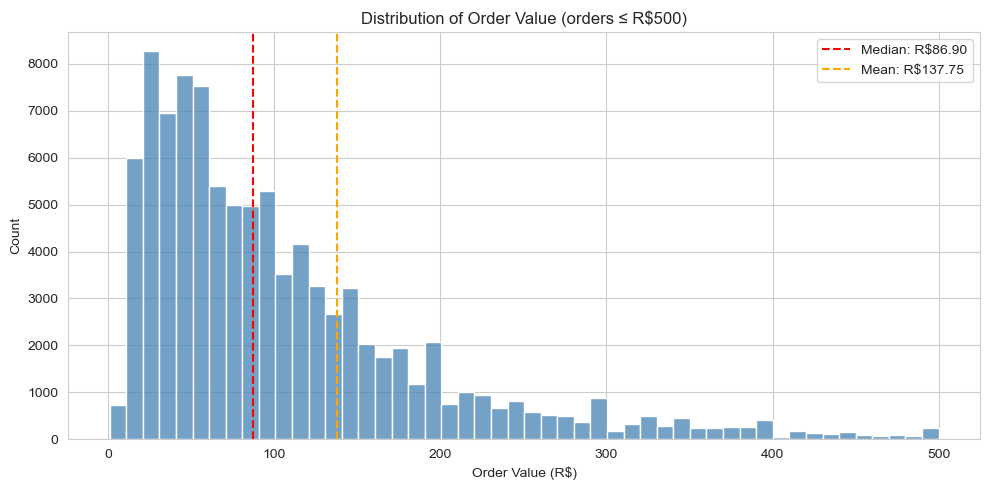

In [8]:
plt.figure(figsize=(10, 5))
# Clip extreme outliers just for visualization clarity (data itself is untouched)
sns.histplot(order_value[order_value['order_value'] <= 500]['order_value'], bins=50, color='steelblue')
plt.axvline(order_value['order_value'].median(), color='red', linestyle='--', label=f"Median: R$86.90")
plt.axvline(order_value['order_value'].mean(), color='orange', linestyle='--', label=f"Mean: R$137.75")
plt.title('Distribution of Order Value (orders ≤ R$500)')
plt.xlabel('Order Value (R$)')
plt.legend()
plt.tight_layout()
plt.savefig('../images/order_value_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight** The typical order is modest — a median value of R$86.90, with 90% of orders containing just a single item. The distribution is right-skewed (mean R$137.75), driven by a smaller number of higher-value, often multi-item orders. Price clustering around common retail price points (e.g., R$29.90, R$49.90) is visible in the distribution.

## 5. Revenue by State

**Question:** Which states drive the most revenue, and does that come from volume or spend-per-order?

In [9]:
state_revenue = analysis_df.groupby('customer_state').agg(
    total_revenue=('price', 'sum'),
    order_count=('order_id', 'nunique')
).reset_index().sort_values('total_revenue', ascending=False)

state_revenue['avg_order_value'] = state_revenue['total_revenue'] / state_revenue['order_count']

state_revenue.head(10)

,customer_state,total_revenue,order_count,avg_order_value
25,SP,5202955.05,41375,125.751179
18,RJ,1824092.67,12762,142.931568
10,MG,1585308.03,11544,137.327445
22,RS,750304.02,5432,138.126661
17,PR,683083.76,4998,136.671421
23,SC,520553.34,3612,144.117757
4,BA,511349.99,3358,152.278139
6,DF,302603.94,2125,142.401854
8,GO,294591.95,2007,146.782237
7,ES,275037.31,2025,135.820894


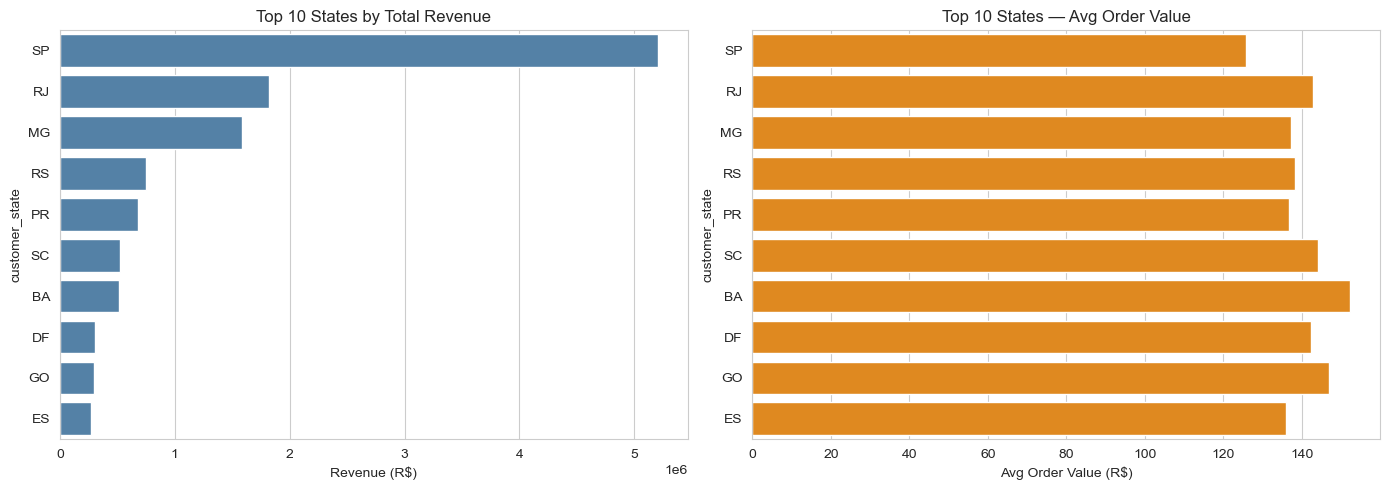

In [10]:
top10 = state_revenue.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=top10, x='total_revenue', y='customer_state', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 States by Total Revenue')
axes[0].set_xlabel('Revenue (R$)')

sns.barplot(data=top10, x='avg_order_value', y='customer_state', ax=axes[1], color='darkorange')
axes[1].set_title('Top 10 States — Avg Order Value')
axes[1].set_xlabel('Avg Order Value (R$)')

plt.tight_layout()
plt.savefig('../images/state_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight** Revenue is heavily concentrated geographically — São Paulo alone generates R5.2M (2.8x the next state), and the top 5 states account for ~74% of total revenue. Notably, SP's dominance comes from order volume, not higher spending per order — its average order value (R$125.75) is actually among the lowest of the top 10 states.

## 6. Payment Methods & Order Value

**Question:** What payment methods do customers use, and how does that relate to order value?

In [11]:
order_level = analysis_df.groupby('order_id').agg(
    order_value=('price', 'sum'),
    payment_type=('payment_type_first', 'first'),
    installments=('payment_installments_max', 'first')
).reset_index()

payment_summary = order_level.groupby('payment_type').agg(
    order_count=('order_id', 'nunique'),
    avg_order_value=('order_value', 'mean'),
    avg_installments=('installments', 'mean')
).reset_index().sort_values('order_count', ascending=False)

payment_summary

,payment_type,order_count,avg_order_value,avg_installments
1,credit_card,74883,143.399652,3.528838
0,boleto,19614,121.929523,1.000000
3,voucher,2648,105.043829,1.469411
2,debit_card,1520,120.809770,1.000000


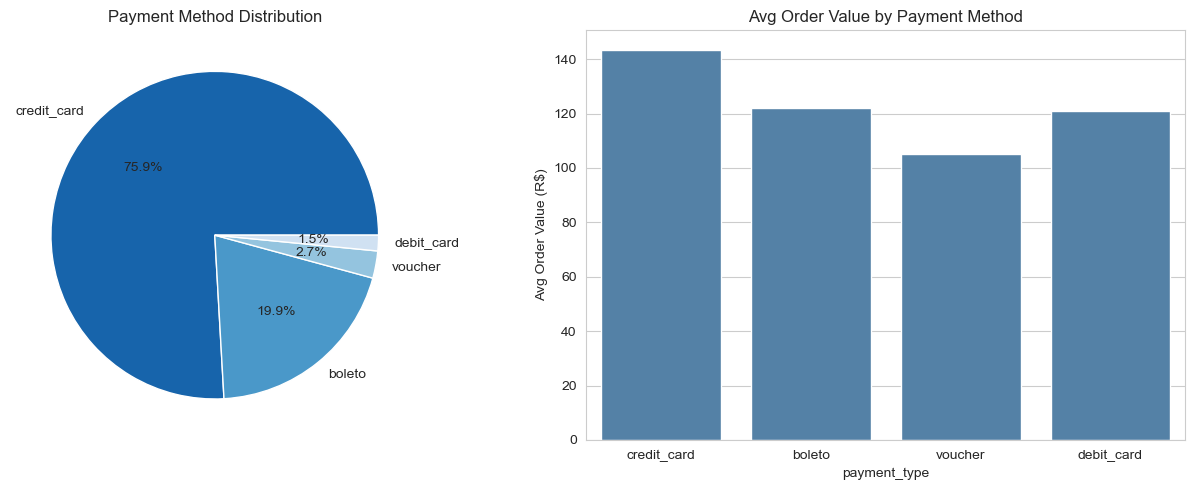

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(payment_summary['order_count'], labels=payment_summary['payment_type'], 
            autopct='%1.1f%%', colors=sns.color_palette('Blues_r', len(payment_summary)))
axes[0].set_title('Payment Method Distribution')

sns.barplot(data=payment_summary, x='payment_type', y='avg_order_value', ax=axes[1], color='steelblue')
axes[1].set_title('Avg Order Value by Payment Method')
axes[1].set_ylabel('Avg Order Value (R$)')

plt.tight_layout()
plt.savefig('../images/payment_methods.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Credit card is the dominant payment method (75.9% of orders) and is associated with 
the highest average order value (R$143.40) and highest installment usage (~3.5 on average) — 
suggesting installment plans enable higher-value purchases. Boleto (19.9% of orders) and debit card 
are strictly single-payment methods (avg installments = 1.0 by definition), consistent with 
lower average order values.

## Summary — Key Sales Insights

1. **Growth then plateau:** Monthly revenue grew steadily through 2017, peaked sharply in 
   November 2017 (R$1.01M — Black Friday), then stabilized at R$850K–1M/month through mid-2018, 
   indicating the business matured from a growth phase into a stable-volume phase within ~18 months.

2. **November is the clear seasonal peak:** Normalized for uneven year-coverage, November generates 
   ~40% more revenue than the average month, driven by Black Friday. Outside November, demand is 
   fairly stable year-round, with a modest post-holiday dip in January–February.

3. **Typical order is modest:** Median order value is R$86.90 (mean R$137.75, pulled up by a 
   right-skewed tail of higher-value orders). ~90% of orders contain just one item.

4. **Revenue is geographically concentrated:** São Paulo alone generates R$5.2M — 2.8x the next 
   state (RJ) — and the top 5 states account for ~74% of total revenue. This concentration comes 
   from order volume, not higher spend-per-order (SP's avg order value is among the lowest of the 
   top 10 states).

5. **Credit card drives higher-value purchases:** Credit card is used in 75.9% of orders and has 
   both the highest average order value (R$143.40) and highest average installment count (~3.5), 
   suggesting installment plans enable customers to make larger purchases.

**Next steps:** Product and customer-level patterns explored in `03_eda_product_customer.ipynb`; 
delivery performance in `04_eda_delivery.ipynb`.